<a href="https://colab.research.google.com/github/nngiabao/AIDevFundamental/blob/main/GermanTrafficSignRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#link: https://www.kaggle.com/code/muskanverma24/traffic-sign-recognition-using-cnn

In [12]:
from google.colab import files
files.upload()

{}

In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets list | head

ref                                                  title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                             Heart Disease                                   3491  2025-12-11 15:29:14.327000           2114        204  1.0              
ahmeduzaki/wind-and-solar-energy-production-dataset  Wind & Solar Energy Production Dataset        395372  2026-01-02 21:06:22.780000              0         35  1.0              
kundanbedmutha/exam-score-prediction-dataset         Exam Score Prediction Dataset                 325454  2025-11-28 07:29:01.047000           5863        249  1.0              
guriya79/heart-failure-prediction-dataset            Heart Failure Clinical Records Study            4067

In [4]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
 93% 567M/612M [00:03<00:00, 92.8MB/s]
100% 612M/612M [00:03<00:00, 186MB/s] 


In [5]:
!unzip gtsrb-german-traffic-sign.zip -d traffic_signs


Streaming output truncated to the last 5000 lines.
  inflating: traffic_signs/train/5/00005_00053_00010.png  
  inflating: traffic_signs/train/5/00005_00053_00011.png  
  inflating: traffic_signs/train/5/00005_00053_00012.png  
  inflating: traffic_signs/train/5/00005_00053_00013.png  
  inflating: traffic_signs/train/5/00005_00053_00014.png  
  inflating: traffic_signs/train/5/00005_00053_00015.png  
  inflating: traffic_signs/train/5/00005_00053_00016.png  
  inflating: traffic_signs/train/5/00005_00053_00017.png  
  inflating: traffic_signs/train/5/00005_00053_00018.png  
  inflating: traffic_signs/train/5/00005_00053_00019.png  
  inflating: traffic_signs/train/5/00005_00053_00020.png  
  inflating: traffic_signs/train/5/00005_00053_00021.png  
  inflating: traffic_signs/train/5/00005_00053_00022.png  
  inflating: traffic_signs/train/5/00005_00053_00023.png  
  inflating: traffic_signs/train/5/00005_00053_00024.png  
  inflating: traffic_signs/train/5/00005_00053_00025.png  
  inf

In [9]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [10]:
# Visualizing Class Distribution
import plotly.express as px
import os

# Path to your training data
train_path = '/content/traffic_signs/Train'
data_list = []
classes = []

for i in range(43):
    path = os.path.join(train_path, str(i))
    images = os.listdir(path)
    data_list.append(len(images))
    classes.append(str(i))

# Creating a beautiful bar chart for distribution
fig = px.bar(x=classes, y=data_list, labels={'x': 'Class ID', 'y': 'Number of Images'},
             title='Distribution of Images per Class', color=data_list)
fig.show()

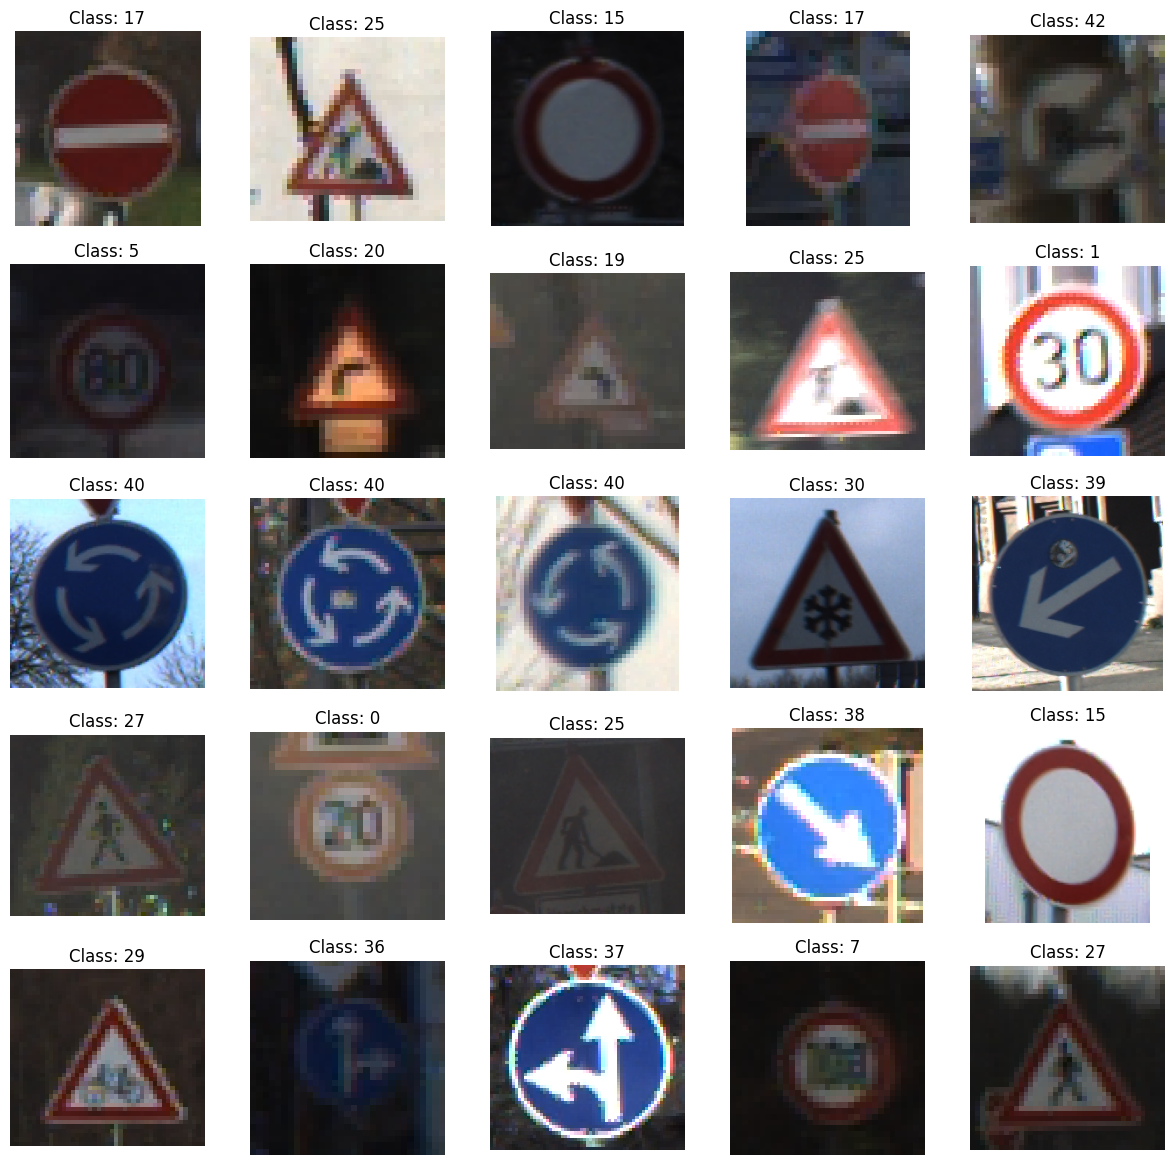

In [11]:
# Visualizing Sample Images
import random

# Visualizing random samples from the dataset
plt.figure(figsize=(12, 12))
for i in range(1, 26):
    plt.subplot(5, 5, i)
    plt.tight_layout()

    # Pick a random class and a random image from it
    rand_class = random.randint(0, 42)
    path = os.path.join(train_path, str(rand_class))
    rand_img = random.choice(os.listdir(path))
    #
    img = Image.open(os.path.join(path, rand_img))
    plt.imshow(img)
    plt.title(f'Class: {rand_class}')
    plt.axis('off')

plt.show()

# **Data processing**

In [15]:
data= []
labels = []
classes = 43
cur_path = os.getcwd()

#loading trainning images
for i in range(classes):
    path = os.path.join(train_path, str(i))
    images = os.listdir(path)

    for a in images:
        try:
            image = Image.open(path + '/'+ a)
            image = image.resize((30,30))
            image = np.array(image)
            data.append(image)
            labels.append(i)
        except Exception as e:
            print(e)
#converting list to numpy arrays
data = np.array(data)
labels = np.array(labels)
#
print(f"Total images loaded: {data.shape[0]}")
print(f"Shape of data: {data.shape}")

Total images loaded: 39209
Shape of data: (39209, 30, 30, 3)


In [16]:
#Standardizzing the image data
X_data = np.array(data)

#Normalization
X_data = X_data.astype('float32') / 255.0
y_labels = np.array(labels)

#Train test split
X_train, X_val, y_train, y_val = train_test_split(X_data, y_labels, test_size=0.2, random_state=42)

#one-hot encoding for the labels
y_train = to_categorical(y_train, 43)
y_val = to_categorical(y_val, 43)

#Defining the augmentation strat
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    fill_mode="nearest"
)

print(f"Final Training shape: {X_train.shape}")
print(f"Final Validation shape: {X_val.shape}")

Final Training shape: (31367, 30, 30, 3)
Final Validation shape: (7842, 30, 30, 3)


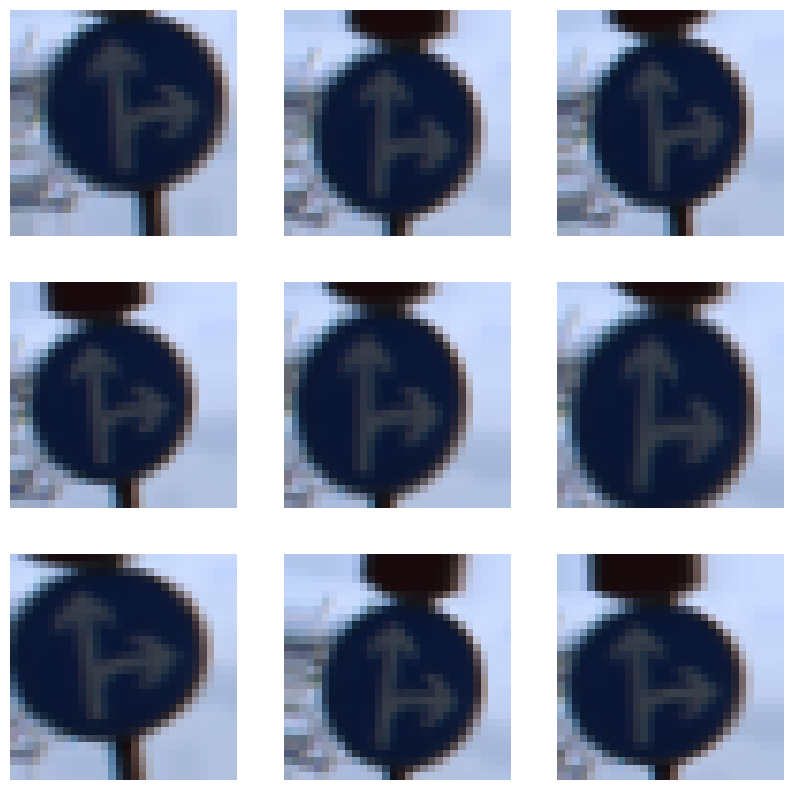

In [20]:
# Visualization of Augmented Images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i +1)
    # Generating a batch of augmented images
    batch = aug.flow(np.expand_dims(X_train[0], 0), batch_size=1)
    img = batch[0][0]
    plt.imshow(img)
    plt.axis('off')
plt.show()

# CNN MODEL ARCHITECTURE

In [21]:
model = Sequential()
#First Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

#Second Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# Flattening and Fully Connected Layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax')) # 43 classes for 43 signs

#Compilation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,251 (946.29 KB)

 Trainable params: 242,251 (946.29 KB)

 Non-trainable params: 0 (0.00 B)

# Model Trainning

In [22]:
epochs = 10
batch_size = 32

# Training the model
history = model.fit(
    aug.flow(X_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



981/981 ━━━━━━━━━━━━━━━━━━━━ 105s 104ms/step - accuracy: 0.2266 - loss: 2.8177 - val_accuracy: 0.8601 - val_loss: 0.4665
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 103s 105ms/step - accuracy: 0.7501 - loss: 0.7915 - val_accuracy: 0.9703 - val_loss: 0.1124
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 98s 99ms/step - accuracy: 0.8728 - loss: 0.4146 - val_accuracy: 0.9866 - val_loss: 0.0556
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 98s 99ms/step - accuracy: 0.9133 - loss: 0.2760 - val_accuracy: 0.9909 - val_loss: 0.0411
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 99ms/step - accuracy: 0.9306 - loss: 0.2327 - val_accuracy: 0.9875 - val_loss: 0.0453
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 102s 104ms/step - accuracy: 0.9457 - loss: 0.1797 - val_accuracy: 0.9926 - val_loss: 0.0289
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 97s 99ms/step - accuracy: 0.9493 - loss: 0.1664 - val_accuracy: 0.9943 - val_loss: 0.0178
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 96s 98ms/step - accuracy: 0.9567 - loss: 0.1448 - val_

# Evaluation

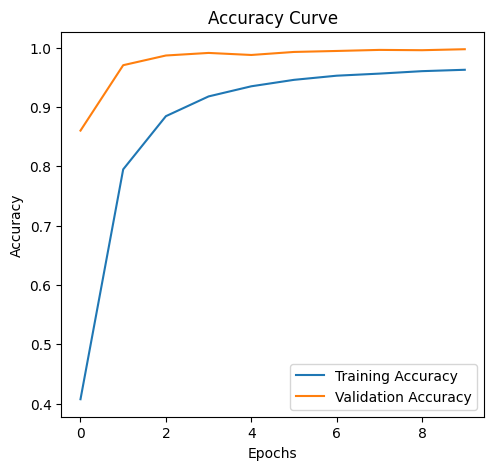

In [23]:
#Plotting the accuracy and the loss
plt.figure(figsize=(12, 5))

#Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# TESTING ON UNSEEN DATA

In [25]:
# Loading the test dataset
test_df = pd.read_csv('/content/traffic_signs/Test.csv')
y_test = test_df["ClassId"].values
imgs = test_df["Path"].values

data = []

# Processing test images exactly like we did for training
for img in imgs:
    try:
        # Correct the path to load images
        image = Image.open('/content/traffic_signs/' + img)
        image = image.resize((30,30))
        data.append(np.array(image))
    except Exception as e:
        print(f"Error loading test image: {img}, Error: {e}")

X_test = np.array(data)

# Normalization
X_test = X_test.astype('float32') / 255.0

# Making predictions
predictions = model.predict(X_test)
classes_x = np.argmax(predictions, axis=1)

# Calculating Accuracy with Test Data
print(f"Final Test Accuracy: {accuracy_score(y_test, classes_x) * 100:.2f}%")

395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step
Final Test Accuracy: 97.58%


# PERFORMANCE ANALYSIS

In [26]:
# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, classes_x))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.99      1.00      0.99       720
           2       0.96      0.99      0.98       750
           3       0.99      0.95      0.97       450
           4       1.00      0.98      0.99       660
           5       0.96      0.95      0.96       630
           6       0.99      0.96      0.98       150
           7       0.99      0.98      0.99       450
           8       0.99      1.00      0.99       450
           9       0.98      1.00      0.99       480
          10       1.00      1.00      1.00       660
          11       0.94      0.93      0.93       420
          12       1.00      0.99      0.99       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.99      0.99      0.99       210
          16       0.99      1.00      1.00       150
    

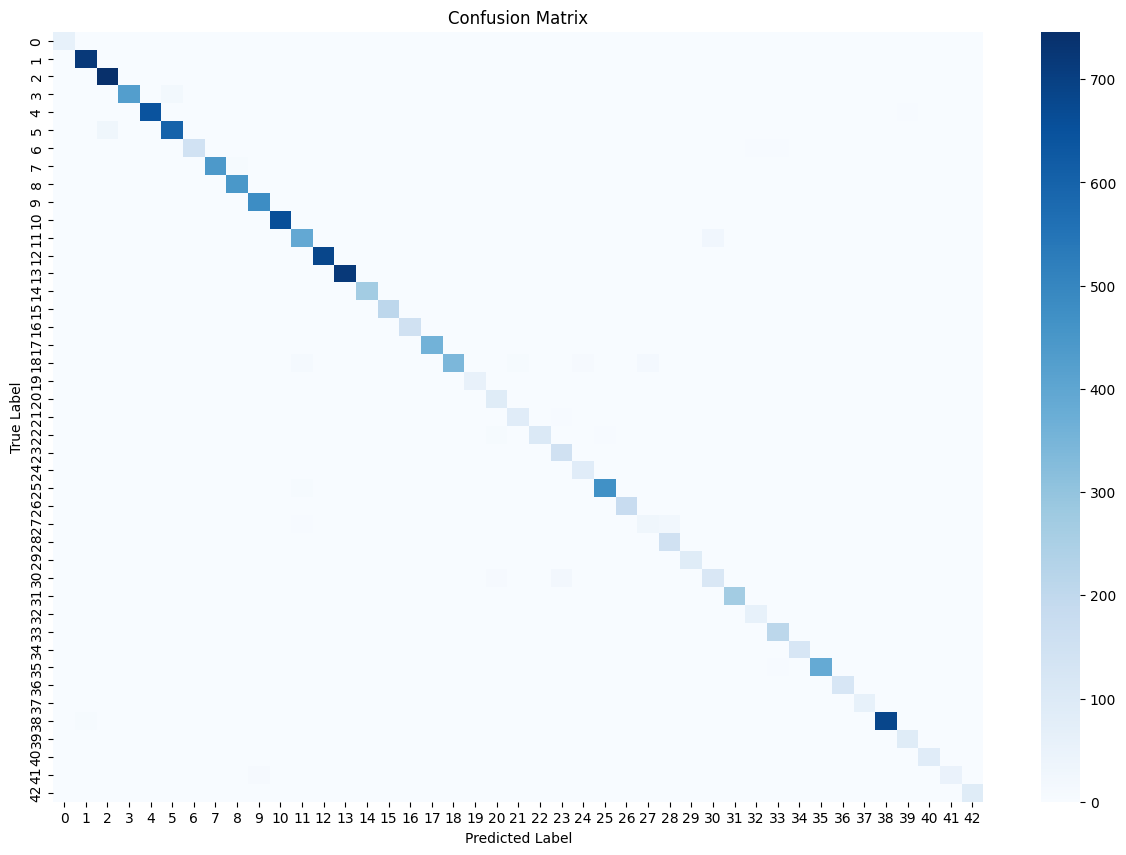

In [27]:
# Confusion Matrix Visualization
plt.figure(figsize=(15, 10))
cm = confusion_matrix(y_test, classes_x)
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# FINAL PREDICTION PREVIEW

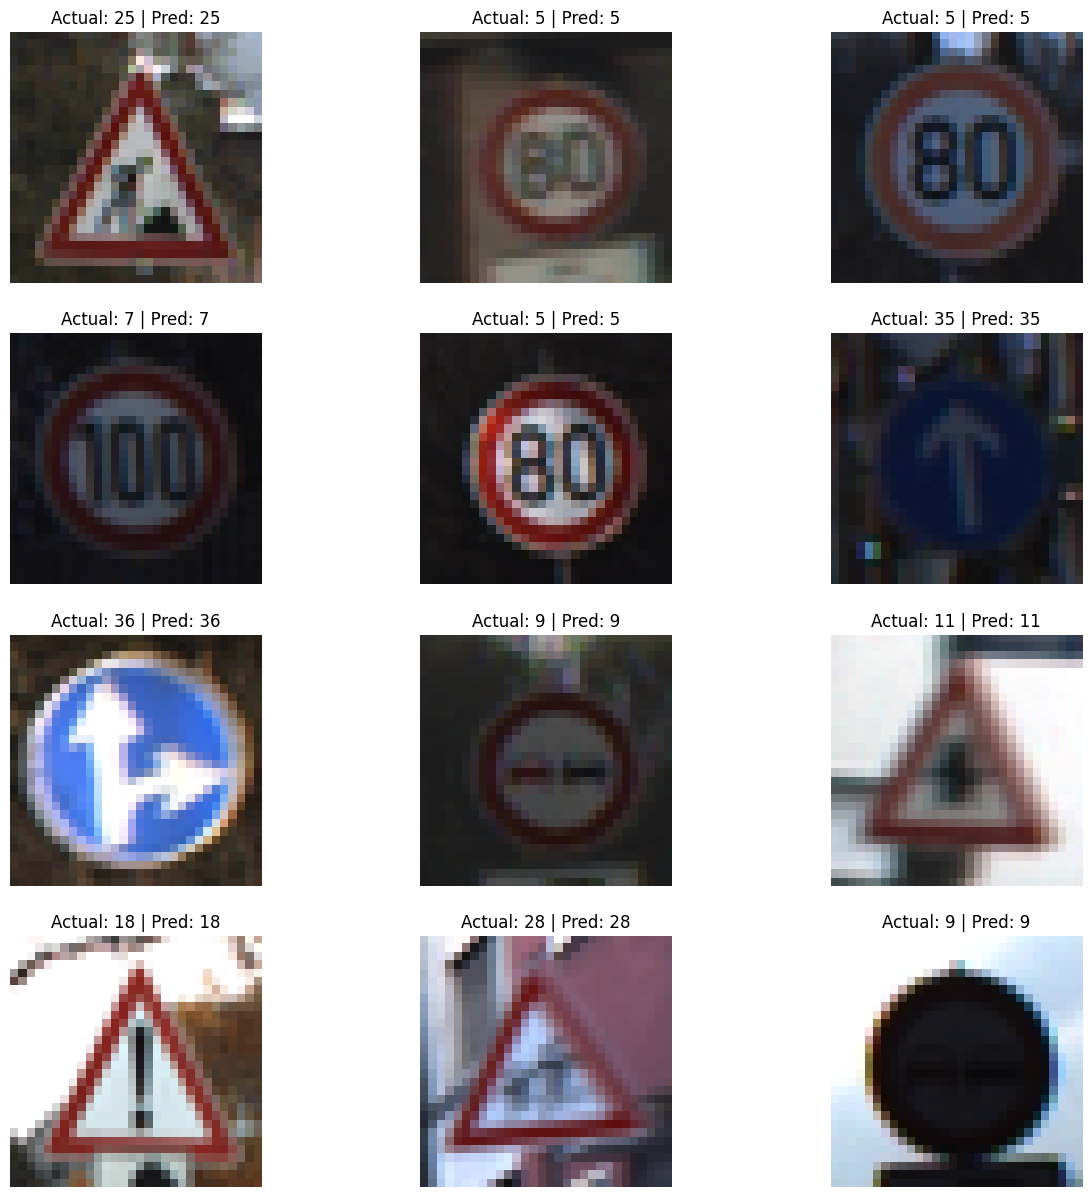

In [28]:
plt.figure(figsize=(15, 15))
for i in range(12):
    plt.subplot(4, 3, i + 1)
    index = random.randint(0, len(X_test))
    plt.imshow(X_test[index])
    plt.title(f"Actual: {y_test[index]} | Pred: {classes_x[index]}")
    plt.axis('off')
plt.show()

In [29]:
# Model saving
model.save('traffic_classifier.h5')
print("Model saved successfully as traffic_classifier.h5")

Model saved successfully as traffic_classifier.h5
